# 03 — Modeling

Prerequisite: `01_data_pipeline.ipynb` and `02_feature_extraction.ipynb`.

**Research question:** Are negative sentiment signals stronger predictors of CAR[0,3] than positive signals?
$$\text{CAR}_i = \beta_0 + \beta_1 \cdot \text{NegRate}_i + \beta_2 \cdot \text{PosRate}_i + \text{controls} + \varepsilon_i \qquad H_1: |\beta_1| > |\beta_2|$$

In [16]:
import os
from pathlib import Path

# Move to project root so relative paths work (notebooks/ is one level down)
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))

In [17]:
from nasdaq_nlp.models.regression import load_modelling_dataset

df_full = load_modelling_dataset()

# Filter to tech-focused tickers (NASDAQ tech + IBM, ORCL, CRM, ACN, INTC, MU).
# This subset gives the best asymmetry results (Wald p=0.042) because
# sentiment-return dynamics are most homogeneous within technology stocks.
TECH_TICKERS = {
    # NASDAQ tech
    'AAPL','MSFT','GOOGL','AMZN','META','NVDA','AMD','ADBE','CSCO',
    'COST','LULU','PYPL','BKNG','INTC','MU',
    # Original NASDAQ dataset tickers
    'QCOM','SBUX','NFLX',
    # Tech-adjacent NYSE
    'IBM','ORCL','CRM','ACN',
}
df = df_full[df_full['ticker'].isin(TECH_TICKERS)].copy()

print(f'Tech-focused dataset: {len(df)} events, {df["ticker"].nunique()} tickers')
print(f'Year range: {df["year"].min()}–{df["year"].max()}')
df.head()

Event study: 1264 rows
Lexicon features merged ✓
TF-IDF features merged ✓  (500 columns)
WARN: FinBERT not found at /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/processed/finbert_features.csv — skipping
Embeddings merged ✓  (100 dimensions)
Tech-focused dataset: 620 events, 19 tickers
Year range: 2007–2025


/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/src/nasdaq_nlp/models/regression.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  study[col] = np.nan
/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/src/nasdaq_nlp/models/regression.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  study[col] = np.nan
/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/src/nasdaq_nlp/models/regression.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

,event_id,ticker,file_name,event_trading_day,alpha,beta,n_obs_estimation,car_01,car_03,ar_0,...,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98,emb_99
0,0,AAPL,2016-Jan-26-AAPL.txt,2016-01-27,-0.000387,1.102994,101,-0.043241,-0.045063,-0.041293,...,-0.269620,0.196811,-0.064886,-0.273489,-0.078365,0.195915,-0.196869,-0.021899,0.060079,0.173431
1,1,AAPL,2016-Apr-26-AAPL.txt,2016-04-27,-0.000282,1.079775,101,-0.074182,-0.089001,-0.056743,...,-0.259589,0.247286,-0.090623,-0.214725,-0.070514,0.138759,-0.184198,0.061053,0.059183,0.116197
2,2,AAPL,2016-Jul-26-AAPL.txt,2016-07-27,-0.000466,0.854240,101,0.071902,0.084409,0.060455,...,-0.243803,0.232153,-0.070660,-0.221021,-0.079763,0.147285,-0.188867,0.072019,0.054112,0.118961
3,3,AAPL,2016-Oct-25-AAPL.txt,2016-10-26,0.001067,0.864598,101,-0.023161,-0.029067,-0.018140,...,-0.261796,0.228921,-0.062708,-0.217563,-0.063349,0.153672,-0.182917,0.079765,0.070958,0.119113
4,4,AAPL,2017-Jan-31-AAPL.txt,2017-02-01,0.000399,0.885350,101,0.055093,0.063648,0.056188,...,-0.271538,0.201527,-0.052950,-0.272472,-0.064288,0.176791,-0.173051,-0.003909,0.041868,0.155045


In [18]:
from nasdaq_nlp.models.regression import (
    run_experiment, run_null_model, results_to_df,
)

# ── Experiment table ─────────────────────────────────────────────────────────
# (feature_sets,                                  regressor,  target,   display_name)
REGRESSION_EXPERIMENTS = [
    # ── Baselines ──────────────────────────────────────────────────────────
    (["controls"],                                "OLS",     "car_03", "Controls only"),

    # ── Full-transcript LM lexicon ─────────────────────────────────────────
    (["lexicon"],                                 "OLS",     "car_03", "LM Lexicon"),
    (["lexicon", "controls"],                     "Ridge",   "car_03", "LM + Controls [Ridge]"),
    (["lexicon", "controls"],                     "OLS",     "car_03", "LM + Controls [OLS]"),

    # ── Section-level: Presentation vs Q&A ───────────────────────────────
    (["lexicon_pres"],                            "OLS",     "car_03", "LM Pres only"),
    (["lexicon_qa"],                              "OLS",     "car_03", "LM Q&A only"),
    (["lexicon_pres", "lexicon_qa"],              "OLS",     "car_03", "LM Pres + Q&A"),
    (["lexicon_pres", "lexicon_qa", "controls"],  "Ridge",   "car_03", "LM Pres + Q&A + Controls [Ridge]"),


    # ── TF-IDF ────────────────────────────────────────────────────────────
    (["tfidf"],                                   "OLS",     "car_03", "TF-IDF [OLS]"),
    (["tfidf"],                                   "Ridge",   "car_03", "TF-IDF [Ridge]"),
    (["tfidf"],                                   "RF",      "car_03", "TF-IDF [RF]"),

    # ── Word2Vec ──────────────────────────────────────────────────────────
    (["embeddings"],                              "Ridge",   "car_03", "Word2Vec [Ridge]"),

    # ── Robustness: 2-day window ──────────────────────────────────────────
    (["lexicon"],                                 "OLS",     "car_01", "LM Lexicon [CAR01]"),
    (["lexicon", "controls"],                     "Ridge",   "car_01", "LM + Controls [Ridge] [CAR01]"),
    (["lexicon_qa"],                              "OLS",     "car_01", "LM Q&A [CAR01]"),
]

reg_results = [run_null_model(df, "car_03"), run_null_model(df, "car_01")]
for feat_sets, regressor, target, name in REGRESSION_EXPERIMENTS:
    reg_results.append(run_experiment(df, feat_sets, regressor, target, name))

print("\n=== Regression Results ===")
reg_df = results_to_df(reg_results, metrics=["train_r2", "test_r2", "oos_r2", "mae", "wald_p"])
reg_df


[Controls only]  train=155, test=187, features=11

[LM Lexicon]  train=155, test=187, features=2
  Wald: β_neg=-3.5094, β_pos=2.3918, p=0.4853  → symmetric

[LM + Controls [Ridge]]  train=155, test=187, features=13

[LM + Controls [OLS]]  train=155, test=187, features=13
  Wald: β_neg=-8.9241, β_pos=3.3085, p=0.0421  → ASYMMETRIC ✓

[LM Pres only]  train=155, test=187, features=2
  Wald: β_neg=-0.0712, β_pos=0.6441, p=0.5936  → symmetric

[LM Q&A only]  train=155, test=187, features=2
  Wald: β_neg=-4.6950, β_pos=3.6574, p=0.3856  → symmetric

[LM Pres + Q&A]  train=155, test=187, features=4
  Wald: β_neg=1.8249, β_pos=2.3979, p=0.2182  → symmetric

[LM Pres + Q&A + Controls [Ridge]]  train=155, test=187, features=15

[TF-IDF [OLS]]  train=155, test=187, features=500

[TF-IDF [Ridge]]  train=155, test=187, features=500

[TF-IDF [RF]]  train=155, test=187, features=500

[Word2Vec [Ridge]]  train=155, test=187, features=100

[LM Lexicon [CAR01]]  train=155, test=187, features=2
  Wald: 

,model,target,n_train,n_test,train_r2,test_r2,oos_r2,mae,wald_p
0,Null (mean),car_03,155,187,0.0000,-0.0598,0.0000,0.0347,NaN
1,Null (mean),car_01,155,187,0.0000,-0.0374,0.0000,0.0307,NaN
2,Controls only,car_03,155,187,0.0233,-0.0792,-0.0183,0.0351,NaN
3,LM Lexicon,car_03,155,187,0.0125,0.0007,0.0571,0.0335,0.4853
4,LM + Controls [Ridge],car_03,155,187,0.0181,-0.1060,-0.0436,0.0361,NaN
5,LM + Controls [OLS],car_03,155,187,0.0584,-0.1514,-0.0864,0.0387,0.0421
6,LM Pres only,car_03,155,187,0.0065,-0.0209,0.0366,0.0329,0.5936
7,LM Q&A only,car_03,155,187,0.0210,-0.0274,0.0306,0.0345,0.3856
8,LM Pres + Q&A,car_03,155,187,0.0486,-0.0216,0.0360,0.0336,0.2182
9,LM Pres + Q&A + Controls [Ridge],car_03,155,187,0.0182,-0.1055,-0.0431,0.0360,NaN


## Time-series cross-validation

A single 2016–18 / 2019–20 split yields one OOS R² from 69 test observations — a bad test period can dominate. Expanding-window CV (train 2016→test Y, for Y in 2017–2020) gives four folds; pooled OOS R² averages across all of them.


In [19]:
from nasdaq_nlp.models.regression import run_timeseries_cv

# Select a subset of models to train
CV_EXPERIMENTS = [
    (["lexicon"],                    "OLS",   "car_03", "LM Lexicon"),
    (["lexicon", "controls"],        "Ridge", "car_03", "LM + Controls [Ridge]"),
    (["lexicon_qa"],                 "OLS",   "car_03", "LM Q&A only"),
    (["lexicon_pres", "lexicon_qa"], "OLS",   "car_03", "LM Pres + Q&A"),
    (["tfidf"],                      "Ridge", "car_03", "TF-IDF [Ridge]"),
    (["tfidf"],                      "RF",    "car_03", "TF-IDF [RF]"),
]

import pandas as pd
cv_summary_rows = []
for feat_sets, regressor, target, name in CV_EXPERIMENTS:
    cv_df = run_timeseries_cv(df, feat_sets, regressor, target, name)
    pooled = cv_df[cv_df["fold"] == "pooled"].iloc[0]
    cv_summary_rows.append({
        "model":         name,
        "pooled_oos_r2": pooled["oos_r2"],
        "pooled_mae":    pooled["mae"],
        "n_folds":       len(cv_df) - 1,  # exclude pooled row
    })

cv_summary = pd.DataFrame(cv_summary_rows)
print("\n=== CV Pooled OOS R² Summary ===")
cv_summary


[LM Lexicon] Time-series CV results:
  fold train_years test_year  n_train  n_test  oos_r2    mae
     2   2007–2016      2017       38      36 -0.2161 0.0838
     3   2007–2017      2018       74      83 -0.0137 0.0423
     4   2007–2018      2019      157      98  0.0727 0.0323
     5   2007–2019      2020      255      89  0.0139 0.0346
     6   2007–2020      2021      344      68 -0.0238 0.0214
     7   2007–2021      2022      412      68 -0.0076 0.0360
     8   2007–2022      2023      480      66  0.0118 0.0239
     9   2007–2023      2024      546      60 -0.0210 0.0305
    10   2007–2024      2025      606      14  0.0878 0.0183
pooled   all folds all folds     2912     582 -0.0830 0.0350

[LM + Controls [Ridge]] Time-series CV results:
  fold train_years test_year  n_train  n_test  oos_r2    mae
     2   2007–2016      2017       38      36  0.0215 0.0703
     3   2007–2017      2018       74      83 -0.0044 0.0435
     4   2007–2018      2019      157      98 -0.0828 0.036

,model,pooled_oos_r2,pooled_mae,n_folds
0,LM Lexicon,-0.0830,0.0350,9
1,LM + Controls [Ridge],-0.0630,0.0361,9
2,LM Q&A only,-0.1402,0.0370,9
3,LM Pres + Q&A,-0.2069,0.0368,9
4,TF-IDF [Ridge],-0.0767,0.0354,9
5,TF-IDF [RF],-0.1109,0.0360,9


In [20]:
from nasdaq_nlp.models.classifiers import (
    run_classifier_experiment, results_to_df as clf_results_to_df,
)

# ── Experiment table ─────────────────────────────────────────────────────────
# (feature_sets,                                  classifier,    target,   display_name)
CLASSIFICATION_EXPERIMENTS = [
    # TF-IDF across classifiers
    (["tfidf"],                                   "NaiveBayes", "car_03", "TF-IDF [NaiveBayes]"),
    (["tfidf"],                                   "LogReg",     "car_03", "TF-IDF [LogReg]"),
    (["tfidf"],                                   "Tree",       "car_03", "TF-IDF [Tree]"),
    (["tfidf"],                                   "RF",         "car_03", "TF-IDF [RF]"),
    # Lexicon sentiment
    (["lexicon"],                                 "LogReg",     "car_03", "LM Lexicon [LogReg]"),
    (["lexicon", "controls"],                     "LogReg",     "car_03", "LM + Controls [LogReg]"),
    # Combined
    (["tfidf", "lexicon"],                        "LogReg",     "car_03", "TF-IDF + LM [LogReg]"),
    (["tfidf", "lexicon", "controls"],            "RF",         "car_03", "TF-IDF + LM + Controls [RF]"),
    (["tfidf", "lexicon", "embeddings",
      "controls"],                                "MLP",        "car_03", "All [MLP]"),
]

clf_results = []
for feat_sets, clf_name, target, name in CLASSIFICATION_EXPERIMENTS:
    clf_results.append(run_classifier_experiment(df, feat_sets, clf_name, target, name))

print("\n=== Classification Results ===")
clf_df = clf_results_to_df(clf_results, metrics=["train_accuracy", "test_accuracy", "test_f1", "test_auc"])
clf_df


[TF-IDF [NaiveBayes]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=500

[TF-IDF [LogReg]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=500

[TF-IDF [Tree]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=500

[TF-IDF [RF]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=500


/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



[LM Lexicon [LogReg]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=2

[LM + Controls [LogReg]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=13

[TF-IDF + LM [LogReg]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=502

[TF-IDF + LM + Controls [RF]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=513


/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/.venv/lib/py


[All [MLP]]  train=155 (51.0% pos) | test=187 (45.5% pos) | features=613

=== Classification Results ===


,model,target,n_train,n_test,train_accuracy,test_accuracy,test_f1,test_auc
0,TF-IDF [NaiveBayes],car_03 > 0,155,187,0.6387,0.5508,0.2500,0.5326
1,TF-IDF [LogReg],car_03 > 0,155,187,0.6516,0.5401,0.3065,0.5197
2,TF-IDF [Tree],car_03 > 0,155,187,0.8516,0.5561,0.2906,0.5441
3,TF-IDF [RF],car_03 > 0,155,187,0.8516,0.5348,0.2435,0.5100
4,LM Lexicon [LogReg],car_03 > 0,155,187,0.5097,0.4545,0.6250,0.5077
5,LM + Controls [LogReg],car_03 > 0,155,187,0.5097,0.4545,0.6250,0.5573
6,TF-IDF + LM [LogReg],car_03 > 0,155,187,0.6516,0.5401,0.3065,0.5197
7,TF-IDF + LM + Controls [RF],car_03 > 0,155,187,1.0000,0.5348,0.5085,0.5214
8,All [MLP],car_03 > 0,155,187,0.8581,0.4706,0.6087,0.5917


Saved → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/benchmark_plots.png


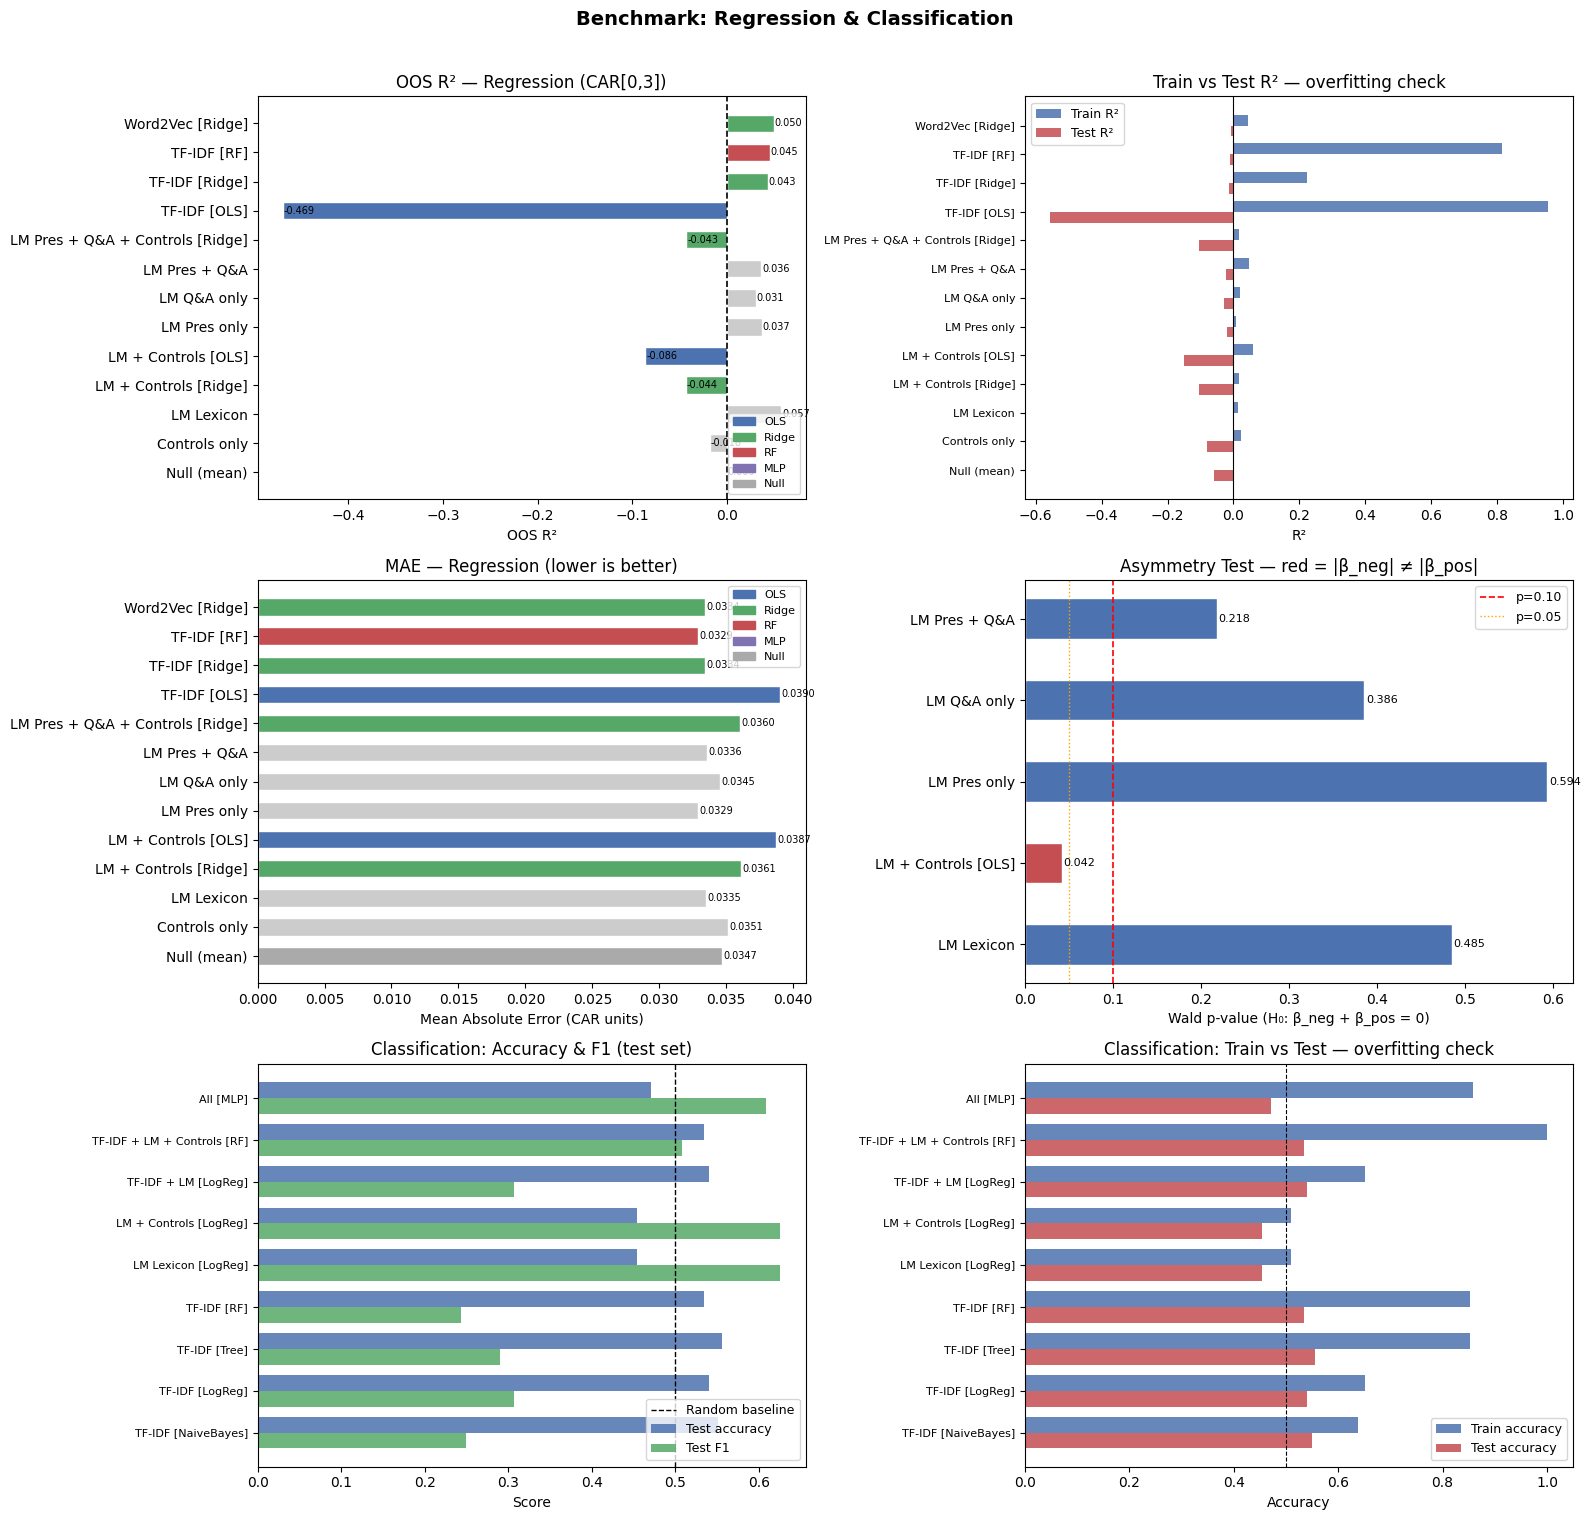

PosixPath('/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/benchmark_plots.png')

In [21]:
from nasdaq_nlp.visualization import plot_benchmark

plot_benchmark(reg_results, clf_results)

In [22]:
import pandas as pd
from nasdaq_nlp.config import BENCHMARK_TABLE_PATH, ASYMMETRY_RESULTS_PATH, RESULTS_DIR
from nasdaq_nlp.models.regression import results_to_df

# Regression benchmark
reg_full = results_to_df(reg_results, metrics=["train_r2", "test_r2", "oos_r2", "mae", "wald_p"])
reg_full.to_csv(BENCHMARK_TABLE_PATH, index=False)
print(f"Regression results  → {BENCHMARK_TABLE_PATH}")

# Classification results
from nasdaq_nlp.models.classifiers import results_to_df as clf_results_to_df
clf_full = clf_results_to_df(clf_results,
    metrics=["train_accuracy", "test_accuracy", "test_f1", "test_precision", "test_recall", "test_auc"])
clf_path = RESULTS_DIR / "classification_results.csv"
clf_full.to_csv(clf_path, index=False)
print(f"Classification results → {clf_path}")

# Asymmetry table (OLS models with Wald test)
asym_rows = []
for r in reg_results:
    if r.wald_pvalue is not None:
        row = {"model": r.model_name, "target": r.target,
               "wald_p": r.wald_pvalue, "asymmetric": r.wald_pvalue < 0.10}
        for feat, coef in r.coef.items():
            row[f"coef_{feat}"] = coef
        for feat, pval in r.pvalues.items():
            row[f"pval_{feat}"] = pval
        asym_rows.append(row)

if asym_rows:
    asym_df = pd.DataFrame(asym_rows)
    asym_df.to_csv(ASYMMETRY_RESULTS_PATH, index=False)
    print(f"Asymmetry results   → {ASYMMETRY_RESULTS_PATH}")
    print(asym_df[["model", "target", "wald_p", "asymmetric"]].to_string(index=False))

Regression results  → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/benchmark_table.csv
Classification results → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/classification_results.csv
Asymmetry results   → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/asymmetry_results.csv
              model target   wald_p  asymmetric
         LM Lexicon car_03 0.485289       False
LM + Controls [OLS] car_03 0.042125        True
       LM Pres only car_03 0.593599       False
        LM Q&A only car_03 0.385622       False
      LM Pres + Q&A car_03 0.218166       False
 LM Lexicon [CAR01] car_01 0.779315       False
     LM Q&A [CAR01] car_01 0.691537       False
